In [2]:
import pandas as pd
import numpy as np
DATA_PATH = "/home/jovyan/work/ner_congressional_records/DATA/"


In [3]:
print(1)

1


In [5]:
train = pd.read_csv(DATA_PATH+"train.csv")
test = pd.read_csv(DATA_PATH+"test.csv")
mi_mn = pd.read_csv(DATA_PATH+"mi_mn_annotated.csv")
mi_mn_balanced = pd.read_csv(DATA_PATH+"mi_mn_balanced.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/home/jovyan/work/ner_congressional_records/DATA/mi_mn_balanced.csv'

In [6]:
mi_mn_balanced = mi_mn_balanced.drop("Unnamed: 0", axis=1)

In [7]:
mi_mn_balanced

,full_name,label
0,butzel long pac butzel long political action c...,0
1,retired detroit police/fire assn pac retired d...,0
2,committee to elect gene haymaker committee to ...,0
3,jack coleman for state representativ jack cole...,0
4,tuscola county republican party tuscola county...,0
...,...,...
9843,"rivera, jose",1
9844,"kropp, rosanne",1
9845,"whitlock, robert b",1
9846,"loe, mike",1


In [62]:
def convert_bool(input_label):
    '''Converts to numerical encoding'''
    if input_label == 'Candidate' or input_label == 'Individual':
        return 1
    else:
        return 0
    
mi_mn['transactor_type'] = np.vectorize(convert_bool)(mi_mn['transactor_type'])


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# preprocessing
# Features and target
X_train = train['full_name'] # name
y_train = train['label'] # label
X_test = test['full_name']
y_test = test['label']
X_mi_mn = mi_mn['merged_full_name']
y_mi_mn = mi_mn['transactor_type']

X_balanced = mi_mn_balanced['full_name']
y_balanced = mi_mn_balanced['label']

# Convert names to numeric features
vectorizer = TfidfVectorizer(stop_words='english', max_features=1000)
# X_tfidf = vectorizer.fit_transform(X_train.fillna(''))  # Handle NaN
# X_mi_mn_tfidf = vectorizer.transform(X_mi_mn.fillna(''))


X_balanced_tfidf = vectorizer.fit_transform(X_balanced.fillna(''))


X_test_tfidf = vectorizer.transform(X_test.fillna(''))

# Train model
model = LogisticRegression(max_iter=1000)
model.fit(X_balanced_tfidf, y_balanced)


LogisticRegression(max_iter=1000)

In [10]:
# Predict
predictions = model.predict(X_test_tfidf)

In [11]:
# scores
# Evaluate
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.99      0.30      0.46     15329
           1       0.59      1.00      0.74     15323

    accuracy                           0.65     30652
   macro avg       0.79      0.65      0.60     30652
weighted avg       0.79      0.65      0.60     30652



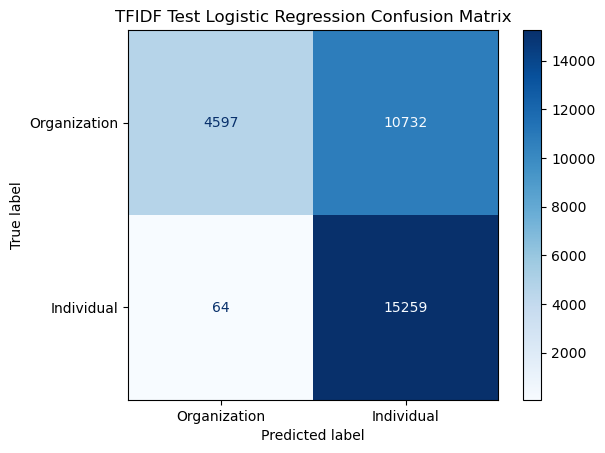

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Confusion matrix
cm = confusion_matrix(y_test, predictions, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Organization', 'Individual'])
disp.plot(cmap=plt.cm.Blues)
plt.title("TFIDF Test Logistic Regression Confusion Matrix")
plt.savefig("Logistic Regression Test set.png", transparent=True, bbox_inches='tight')
plt.show()

In [ ]:
# # Predict
# predictions = model.predict(X_mi_mn_tfidf)
# # scores
# # Evaluate
# from sklearn.metrics import f1_score
# from sklearn.metrics import classification_report
# print(classification_report(y_mi_mn, predictions))

In [ ]:
# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# import matplotlib.pyplot as plt

# #Confusion matrix
# cm = confusion_matrix(y_mi_mn, predictions, labels=[0, 1])
# disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Organization', 'Individual'])
# disp.plot(cmap=plt.cm.Blues)
# plt.title("TFIDF MI-MN Logistic Regression Confusion Matrix")
# plt.savefig("Logistic Regression Test set.png", transparent=True, bbox_inches='tight')
# plt.show()